In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
news_df = pd.read_csv('apple_news_data.csv')

In [3]:
news_df.shape

(29752, 10)

In [4]:
news_df.head()

,date,title,content,link,symbols,tags,sentiment_polarity,sentiment_neg,sentiment_neu,sentiment_pos
0,2024-11-27T16:39:00+00:00,Berkshire Stock Hits Record Even as Company Re...,"Warren Buffett’s caution, his advancing age, a...",https://finance.yahoo.com/m/f5df3aa4-364b-31d6...,"0R2V.IL, AAPL.BA, AAPL.MX, AAPL.NEO, AAPL.SN, ...",NaN,0.0,0.0,1.0,0.0
1,2024-11-26T00:00:00+00:00,What Is a Stock Market Index?,What Is a Stock Market Index?,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMZN.US, MSFT.US",NaN,0.0,0.0,1.0,0.0
2,2024-11-26T00:00:00+00:00,"Could Investing $1,000 in Apple Make You a Mil...","Could Investing $1,000 in Apple Make You a Mil...",https://www.fool.com/investing/2024/11/26/coul...,AAPL.US,NaN,0.0,0.0,1.0,0.0
3,2024-11-26T00:00:00+00:00,Dow Jones Industrial Average,Dow Jones Industrial Average,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMGN.US, AMZN.US, CSCO.US, GOOG.US, G...",NaN,0.0,0.0,1.0,0.0
4,2024-11-26T00:00:00+00:00,What Is the S&P 500 Index?,What Is the S&P 500 Index?,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMZN.US, GOOG.US, GOOGL.US, META.US, ...",NaN,0.0,0.0,1.0,0.0


In [5]:
news_df.tail()

,date,title,content,link,symbols,tags,sentiment_polarity,sentiment_neg,sentiment_neu,sentiment_pos
29747,2018-01-31T12:55:00+00:00,Investor Expectations to Drive Momentum within...,"NEW YORK, Jan. 31, 2018 (GLOBE NEWSWIRE) -- ...",https://www.globenewswire.com/news-release/201...,"AAPL.US, AVHI.US, FARM.US, GM.US, SGRY.US",FUNDAMENTAL MARKETS,0.995,0.009,0.937,0.054
29748,2017-11-30T14:27:00+00:00,"BioTelemetry, Inc. Enters Agreement to Provide...","MALVERN, Pa., Nov. 30, 2017 (GLOBE NEWSWIRE)...",https://www.globenewswire.com/news-release/201...,"AAPL.US, BEAT.US","BIOTELEMETRY, INC, NASDAQ:BEAT",0.989,0.021,0.804,0.174
29749,2017-11-27T13:00:00+00:00,"Factors of Influence in 2018, Key Indicators a...","NEW YORK, Nov. 27, 2017 (GLOBE NEWSWIRE) -- ...",https://www.globenewswire.com/news-release/201...,"AAPL.US, CSCO.US, GD.US, HPE.US, NVDA.US, S.US",FUNDAMENTAL MARKETS,0.997,0.008,0.926,0.065
29750,2017-10-05T15:58:00+00:00,New Research: Key Drivers of Growth for Micros...,"NEW YORK, Oct. 05, 2017 (GLOBE NEWSWIRE) -- ...",https://www.globenewswire.com/news-release/201...,"AAPL.US, AMZN.US, INTC.US, MSFT.US, QCOM.US, T...",FUNDAMENTAL MARKETS,0.997,0.008,0.925,0.067
29751,2016-02-19T15:05:00+00:00,Payment Data Systems Announces Apple Pay Suppo...,"SAN ANTONIO, Feb. 19, 2016 (GLOBE NEWSWIRE) ...",https://www.globenewswire.com/news-release/201...,"AAPL.US, PYDS.US, USIO.US","AKIMBO, AKIMBO CARD, APPLE, APPLE PAY, FICENTI...",0.994,0.023,0.869,0.108


In [6]:
print(news_df.columns)

Index(['date', 'title', 'content', 'link', 'symbols', 'tags',
       'sentiment_polarity', 'sentiment_neg', 'sentiment_neu',
       'sentiment_pos'],
      dtype='str')


In [7]:
news_df['date'] = pd.to_datetime(news_df['date'])

In [8]:
news_df['Date'] = news_df['date'].dt.date

In [9]:
daily_sentiment = (
    news_df.groupby('Date')
    .agg(
        Sentiment=('sentiment_polarity', 'mean'),
        Positive_Sentiment=('sentiment_pos', 'mean'),
        Negative_Sentiment=('sentiment_neg', 'mean'),
        Neutral_Sentiment=('sentiment_neu', 'mean'),
        article_count=('sentiment_polarity', 'count')).reset_index())

In [10]:
daily_sentiment.columns

Index(['Date', 'Sentiment', 'Positive_Sentiment', 'Negative_Sentiment',
       'Neutral_Sentiment', 'article_count'],
      dtype='str')

In [11]:
daily_sentiment.head()

,Date,Sentiment,Positive_Sentiment,Negative_Sentiment,Neutral_Sentiment,article_count
0,2016-02-19,0.994,0.108,0.023,0.869,1
1,2017-10-05,0.997,0.067,0.008,0.925,1
2,2017-11-27,0.997,0.065,0.008,0.926,1
3,2017-11-30,0.989,0.174,0.021,0.804,1
4,2018-01-31,0.995,0.054,0.009,0.937,1


In [12]:
apple_df = pd.read_csv(r"C:\Users\ramya\OneDrive\Desktop\Stock Market prediction project\aapl_cleaned.csv")

In [13]:
print(apple_df.columns)

Index(['Unnamed: 0', 'Date', 'Close', 'High', 'Low', 'Open', 'Volume',
       'Daily_Return', 'MA20', 'MA50', 'Target'],
      dtype='str')


In [14]:
apple_df.head()

,Unnamed: 0,Date,Close,High,Low,Open,Volume,Daily_Return,MA20,MA50,Target
0,0,2016-03-15,23.663523,23.799286,23.498343,23.523233,160270800,0.020093,22.500375,22.146492,23.978039
1,1,2016-03-16,23.978039,24.054970,23.665782,23.670309,153214000,0.013291,22.589186,22.151871,23.939575
2,2,2016-03-17,23.939575,24.091177,23.749506,23.876218,137682800,-0.001604,22.697118,22.168363,23.966730
3,3,2016-03-18,23.966730,24.097968,23.801553,24.061764,176820800,0.001134,22.808896,22.194445,23.964466
4,4,2016-03-21,23.964466,24.358179,23.790236,23.968991,142010800,-0.000094,22.911058,22.239612,24.147743


In [15]:
apple_df = apple_df.drop(columns=['Unnamed: 0'])

In [16]:
apple_df.tail()

,Date,Close,High,Low,Open,Volume,Daily_Return,MA20,MA50,Target
2208,2024-12-20,252.874374,253.381131,244.130238,246.465310,147495300,0.018816,242.209509,233.230406,253.649399
2209,2024-12-23,253.649399,254.026976,251.840946,253.152573,40858800,0.003065,243.471445,233.786255,256.560852
2210,2024-12-24,256.560852,256.570768,253.669307,253.868050,23234700,0.011478,244.729907,234.325892,257.375580
2211,2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,0.003176,245.920300,234.831203,253.967361
2212,2024-12-27,253.967361,257.057633,251.453425,256.193131,42355300,-0.013242,246.946741,235.309442,250.598892


In [17]:
apple_df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return',
       'MA20', 'MA50', 'Target'],
      dtype='str')

In [18]:
apple_df['Date'] = pd.to_datetime(apple_df['Date']).dt.date

In [19]:
daily_sentiment['Date'] = pd.to_datetime(daily_sentiment['Date']).dt.date


In [20]:
merged_df = pd.merge(apple_df, daily_sentiment, on='Date', how='left')

In [21]:
merged_df

,Date,Close,High,Low,Open,Volume,Daily_Return,MA20,MA50,Target,Sentiment,Positive_Sentiment,Negative_Sentiment,Neutral_Sentiment,article_count
0,2016-03-15,23.663523,23.799286,23.498343,23.523233,160270800,0.020093,22.500375,22.146492,23.978039,NaN,NaN,NaN,NaN,NaN
1,2016-03-16,23.978039,24.054970,23.665782,23.670309,153214000,0.013291,22.589186,22.151871,23.939575,NaN,NaN,NaN,NaN,NaN
2,2016-03-17,23.939575,24.091177,23.749506,23.876218,137682800,-0.001604,22.697118,22.168363,23.966730,NaN,NaN,NaN,NaN,NaN
3,2016-03-18,23.966730,24.097968,23.801553,24.061764,176820800,0.001134,22.808896,22.194445,23.964466,NaN,NaN,NaN,NaN,NaN
4,2016-03-21,23.964466,24.358179,23.790236,23.968991,142010800,-0.000094,22.911058,22.239612,24.147743,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2208,2024-12-20,252.874374,253.381131,244.130238,246.465310,147495300,0.018816,242.209509,233.230406,253.649399,NaN,NaN,NaN,NaN,NaN
2209,2024-12-23,253.649399,254.026976,251.840946,253.152573,40858800,0.003065,243.471445,233.786255,256.560852,NaN,NaN,NaN,NaN,NaN
2210,2024-12-24,256.560852,256.570768,253.669307,253.868050,23234700,0.011478,244.729907,234.325892,257.375580,NaN,NaN,NaN,NaN,NaN
2211,2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,0.003176,245.920300,234.831203,253.967361,NaN,NaN,NaN,NaN,NaN


In [22]:
merged_df['Sentiment'] = merged_df['Sentiment'].fillna(0)

merged_df['Positive_Sentiment'] = merged_df['Positive_Sentiment'].fillna(0)

merged_df['Negative_Sentiment'] = merged_df['Negative_Sentiment'].fillna(0)

merged_df['Neutral_Sentiment'] = merged_df['Neutral_Sentiment'].fillna(0)

In [23]:
days_with_news = (merged_df['Sentiment'] != 0).sum()

total_days = len(merged_df)

print("Total trading days:", total_days)
print("Days with news:", days_with_news)
print("Coverage:", round(days_with_news / total_days * 100, 1), "%")

Total trading days: 2213
Days with news: 1127
Coverage: 50.9 %


In [24]:
merged_df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,MA20,MA50,Target,Sentiment,Positive_Sentiment,Negative_Sentiment,Neutral_Sentiment,article_count
0,2016-03-15,23.663523,23.799286,23.498343,23.523233,160270800,0.020093,22.500375,22.146492,23.978039,0.0,0.0,0.0,0.0,NaN
1,2016-03-16,23.978039,24.054970,23.665782,23.670309,153214000,0.013291,22.589186,22.151871,23.939575,0.0,0.0,0.0,0.0,NaN
2,2016-03-17,23.939575,24.091177,23.749506,23.876218,137682800,-0.001604,22.697118,22.168363,23.966730,0.0,0.0,0.0,0.0,NaN
3,2016-03-18,23.966730,24.097968,23.801553,24.061764,176820800,0.001134,22.808896,22.194445,23.964466,0.0,0.0,0.0,0.0,NaN
4,2016-03-21,23.964466,24.358179,23.790236,23.968991,142010800,-0.000094,22.911058,22.239612,24.147743,0.0,0.0,0.0,0.0,NaN


In [25]:
merged_df.shape

(2213, 15)

In [26]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2213 entries, 0 to 2212
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                2213 non-null   object 
 1   Close               2213 non-null   float64
 2   High                2213 non-null   float64
 3   Low                 2213 non-null   float64
 4   Open                2213 non-null   float64
 5   Volume              2213 non-null   int64  
 6   Daily_Return        2213 non-null   float64
 7   MA20                2213 non-null   float64
 8   MA50                2213 non-null   float64
 9   Target              2213 non-null   float64
 10  Sentiment           2213 non-null   float64
 11  Positive_Sentiment  2213 non-null   float64
 12  Negative_Sentiment  2213 non-null   float64
 13  Neutral_Sentiment   2213 non-null   float64
 14  article_count       1132 non-null   float64
dtypes: float64(13), int64(1), object(1)
memory usage: 259.5+ KB


In [27]:
merged_df.isnull().sum()

Date                     0
Close                    0
High                     0
Low                      0
Open                     0
Volume                   0
Daily_Return             0
MA20                     0
MA50                     0
Target                   0
Sentiment                0
Positive_Sentiment       0
Negative_Sentiment       0
Neutral_Sentiment        0
article_count         1081
dtype: int64

In [28]:
merged_df.to_csv("apple_final_dataset.csv",index=False)

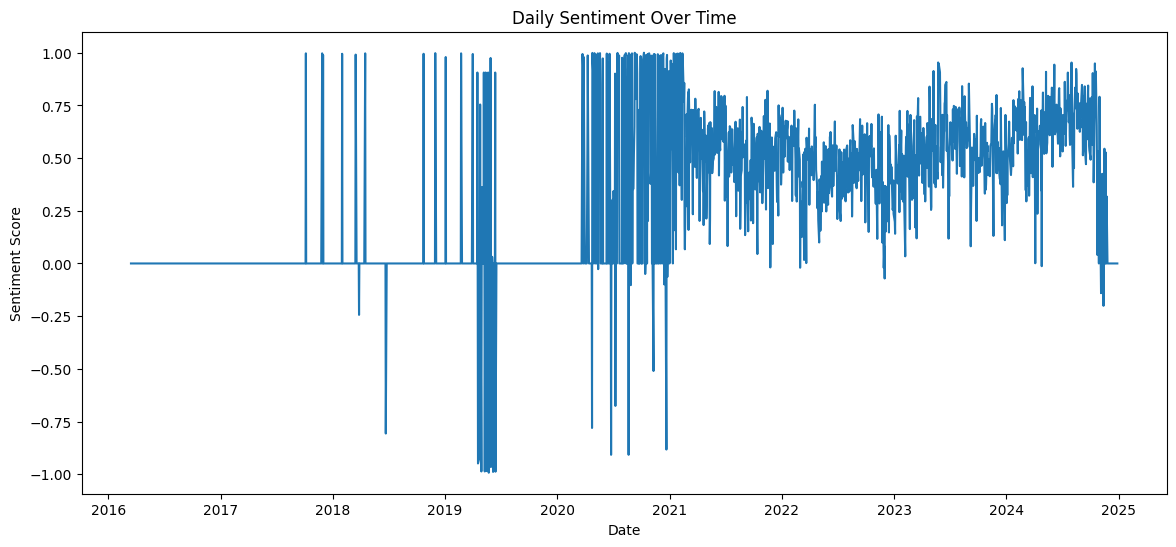

In [29]:
plt.figure(figsize=(14,6))
plt.plot(merged_df['Date'],merged_df['Sentiment'])
plt.title("Daily Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Sentiment Score")
plt.show()

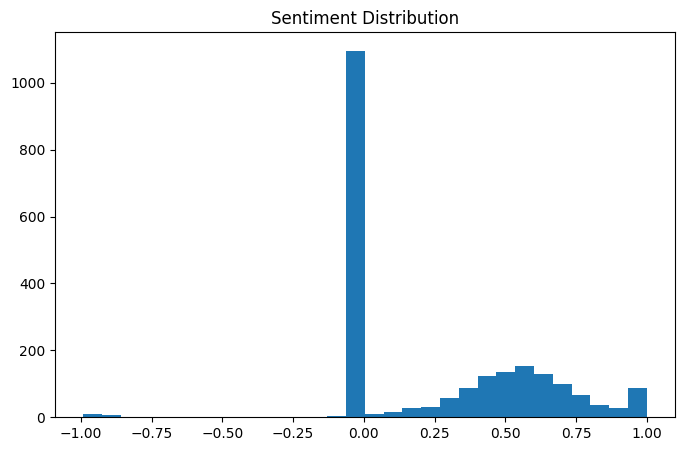

In [30]:
plt.figure(figsize=(8,5))
plt.hist(merged_df['Sentiment'],bins=30)
plt.title("Sentiment Distribution")
plt.show()

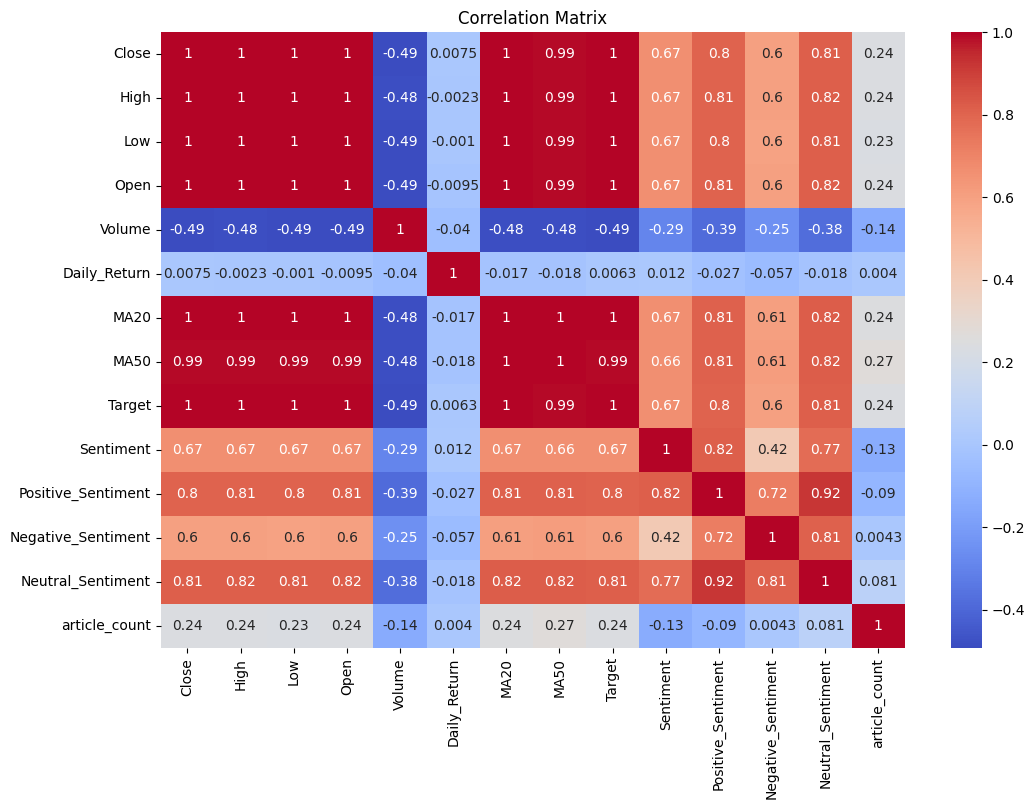

In [31]:
import seaborn as sns

plt.figure(figsize=(12,8))
corr = merged_df.select_dtypes(include='number').corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

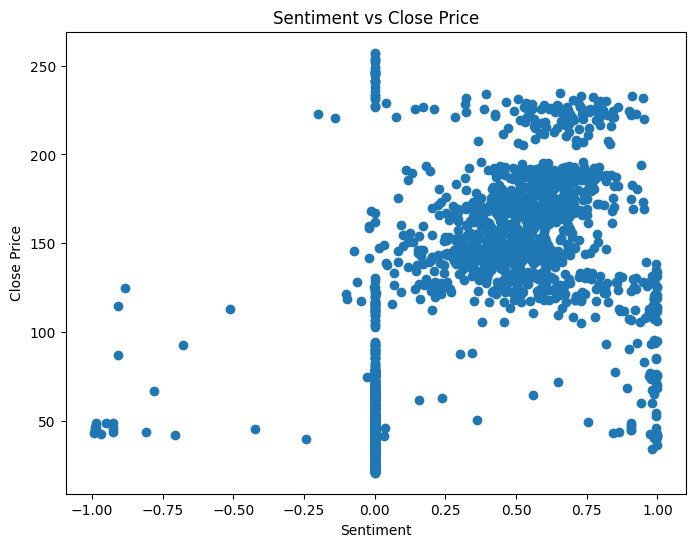

In [33]:
plt.figure(figsize=(8,6))
plt.scatter(merged_df['Sentiment'],merged_df['Close'])
plt.xlabel("Sentiment")
plt.ylabel("Close Price")
plt.title("Sentiment vs Close Price")
plt.show()

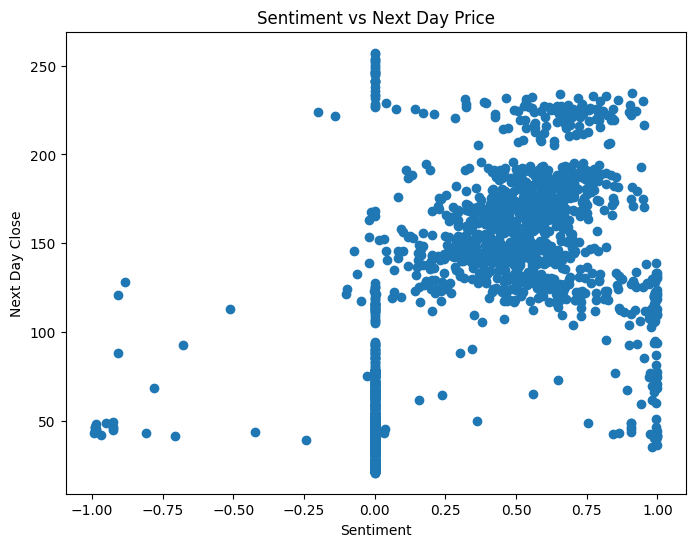

In [34]:
plt.figure(figsize=(8,6))
plt.scatter(merged_df['Sentiment'],merged_df['Target'])
plt.xlabel("Sentiment")
plt.ylabel("Next Day Close")
plt.title("Sentiment vs Next Day Price")
plt.show()

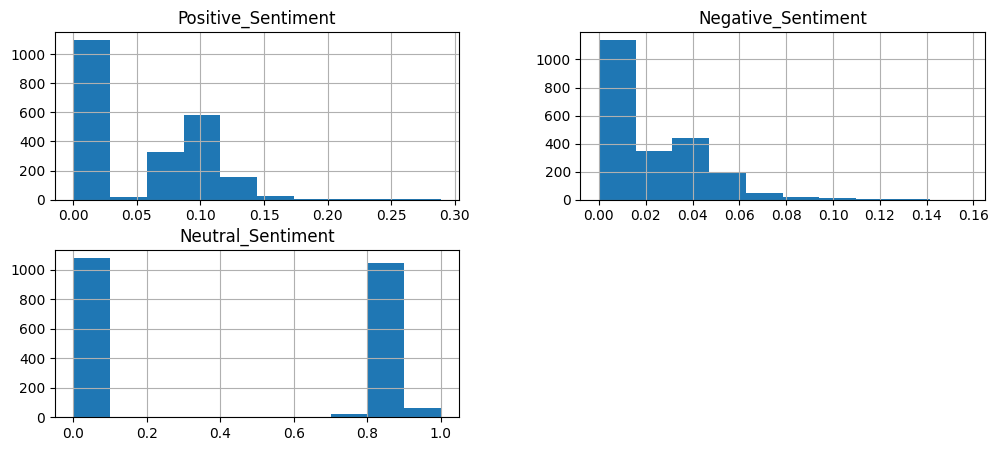

In [35]:
sent_cols = ['Positive_Sentiment','Negative_Sentiment','Neutral_Sentiment']
merged_df[sent_cols].hist(figsize=(12,5))
plt.show()

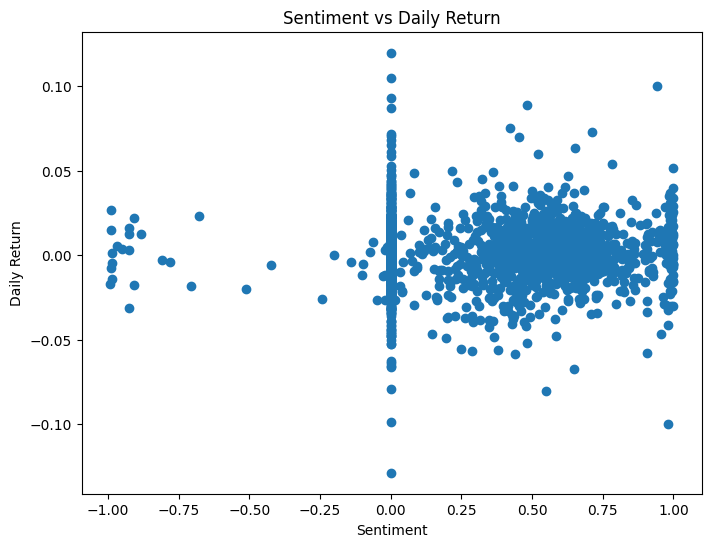

In [36]:
plt.figure(figsize=(8,6))
plt.scatter(merged_df['Sentiment'],merged_df['Daily_Return'])
plt.xlabel("Sentiment")
plt.ylabel("Daily Return")
plt.title("Sentiment vs Daily Return")
plt.show()

In [37]:

merged_df['Lag1'] = merged_df['Close'].shift(1)

merged_df['Lag2'] = merged_df['Close'].shift(2)

merged_df['Lag3'] = merged_df['Close'].shift(3)

merged_df['Lag5'] = merged_df['Close'].shift(5)

In [38]:
merged_df[['Date','Close','Lag1','Lag2','Lag3','Lag5']].head(10)

,Date,Close,Lag1,Lag2,Lag3,Lag5
0,2016-03-15,23.663523,NaN,NaN,NaN,NaN
1,2016-03-16,23.978039,23.663523,NaN,NaN,NaN
2,2016-03-17,23.939575,23.978039,23.663523,NaN,NaN
3,2016-03-18,23.966730,23.939575,23.978039,23.663523,NaN
4,2016-03-21,23.964466,23.966730,23.939575,23.978039,NaN
5,2016-03-22,24.147743,23.964466,23.966730,23.939575,23.663523
6,2016-03-23,24.014250,24.147743,23.964466,23.966730,23.978039
7,2016-03-24,23.910166,24.014250,24.147743,23.964466,23.939575
8,2016-03-28,23.801552,23.910166,24.014250,24.147743,23.966730
9,2016-03-29,24.364967,23.801552,23.910166,24.014250,23.964466


In [39]:
delta = merged_df['Close'].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss

merged_df['RSI'] = 100 - (100 / (1 + rs))

In [40]:
merged_df[['Date','Close','RSI']].tail()

,Date,Close,RSI
2208,2024-12-20,252.874374,75.940104
2209,2024-12-23,253.649399,73.865325
2210,2024-12-24,256.560852,76.180661
2211,2024-12-26,257.375580,76.812031
2212,2024-12-27,253.967361,69.300625


In [41]:
ema12 = merged_df['Close'].ewm(span=12, adjust=False).mean()

ema26 = merged_df['Close'].ewm(span=26, adjust=False).mean()

merged_df['MACD'] = ema12 - ema26

merged_df['Signal_Line'] = merged_df['MACD'].ewm(span=9, adjust=False).mean()

In [42]:
merged_df[['Date','MACD','Signal_Line']].tail()

,Date,MACD,Signal_Line
2208,2024-12-20,5.564926,5.058019
2209,2024-12-23,5.735163,5.193448
2210,2024-12-24,6.035435,5.361845
2211,2024-12-26,6.266904,5.542857
2212,2024-12-27,6.104956,5.655277


In [43]:
merged_df = merged_df.dropna().reset_index(drop=True)

In [44]:
print(merged_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1132 entries, 0 to 1131
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                1132 non-null   object 
 1   Close               1132 non-null   float64
 2   High                1132 non-null   float64
 3   Low                 1132 non-null   float64
 4   Open                1132 non-null   float64
 5   Volume              1132 non-null   int64  
 6   Daily_Return        1132 non-null   float64
 7   MA20                1132 non-null   float64
 8   MA50                1132 non-null   float64
 9   Target              1132 non-null   float64
 10  Sentiment           1132 non-null   float64
 11  Positive_Sentiment  1132 non-null   float64
 12  Negative_Sentiment  1132 non-null   float64
 13  Neutral_Sentiment   1132 non-null   float64
 14  article_count       1132 non-null   float64
 15  Lag1                1132 non-null   float64
 16  Lag2             

In [45]:
merged_df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,MA20,MA50,Target,...,Negative_Sentiment,Neutral_Sentiment,article_count,Lag1,Lag2,Lag3,Lag5,RSI,MACD,Signal_Line
0,2017-10-05,36.193485,36.205132,35.881373,35.911650,85135200,0.012445,36.335905,36.659574,36.172497,...,0.008,0.925,1.0,35.748585,35.981518,35.825451,35.702003,38.064917,-0.284222,-0.258333
1,2017-11-27,40.694866,40.926288,40.519548,40.919275,82867200,-0.005029,40.163732,37.868176,40.456429,...,0.008,0.926,1.0,40.900558,40.898220,40.472790,39.773842,51.324818,0.770903,0.825436
2,2017-11-30,40.171238,40.239026,39.374124,39.839299,166108800,0.013984,40.322109,38.067460,39.984238,...,0.021,0.804,1.0,39.617229,40.456429,40.694866,40.898220,42.328513,0.570635,0.728934
3,2018-01-31,39.138016,39.374113,38.920623,39.007112,129915600,0.002755,40.695436,40.410276,39.219841,...,0.009,0.937,1.0,39.030506,39.261925,40.091763,40.725227,33.186061,-0.231234,0.065413
4,2018-03-16,41.783184,42.041364,41.689298,41.931049,157618800,-0.003526,41.453182,40.421219,41.144764,...,0.011,0.917,1.0,41.931046,41.881760,42.240883,42.243217,47.417043,0.583631,0.574672


In [46]:
merged_df.to_csv("apple_feature_engineered.csv", index=False)